In [ ]:
import joblib
import os
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


marco Labal for user data

In [ ]:
import pandas as pd
import math
import random

# --- Macro Ratios per condition ---
macros_dict = {
    "Bariatric": {"Protein":35,"Carb":40,"Fat":25},
    "Gallbladder": {"Protein":25,"Carb":50,"Fat":25},
    "Kidney": {"Protein":16,"Carb":53,"Fat":31},
    "Diabetes": {"Protein":25,"Carb":42,"Fat":33},
    "Hypertension": {"Protein":22,"Carb":53,"Fat":25},
    "Heart_Disease": {"Protein":20,"Carb":50,"Fat":30},
    "PCOS": {"Protein":20,"Carb":45,"Fat":35},
    "Anemia": {"Protein":22,"Carb":50,"Fat":28},
    "Gout": {"Protein":18,"Carb":55,"Fat":27},
    "Football": {"Protein":25,"Carb":55,"Fat":20},
    "Bodybuilding": {"Protein":30,"Carb":45,"Fat":25},
    "Running": {"Protein":22,"Carb":58,"Fat":20},
    "Yoga": {"Protein":20,"Carb":50,"Fat":30},
    "Default": {"Protein":20,"Carb":50,"Fat":30},
}

# --- Priority weights ---
weights_dict = {
    "Bariatric": random.uniform(0.8, 1.0),  # متغير مش ثابت
    "Gallbladder": random.uniform(0.8, 1.0),
    "Kidney":random.uniform(0.8, 1.0),
    "Diabetes":random.uniform(0.8, 1.0),
    "Hypertension":random.uniform(0.4, 1.0),
    "Heart_Disease":random.uniform(0.4, 1.0),
    "PCOS":random.uniform(0.4, 1.0),
    "Anemia":random.uniform(0.4, 1.0),
    "Gout":random.uniform(0.4, 1.0),
    "Football":random.uniform(0.6, 1.0),
    "Bodybuilding":random.uniform(0.8, 1.0),
    "Running":random.uniform(0.6, 1.0),
    "Yoga":random.uniform(0.6, 1.0),
    "Default":random.uniform(0.3, 1.0)
}

def apply_goal_adjustment(protein, carb, fat, goal, active_conditions):
    if goal == "Fat_Loss":
        if any(cond in active_conditions for cond in ["Kidney", "Gout"]):
            protein += 2
            carb -= 2
        else:
            protein += 5
            carb -= 5
    elif goal == "Muscle_Gain":
        if any(cond in active_conditions for cond in ["Heart_Disease", "Hypertension"]):
            protein += 5
            carb += 3
            fat -= 8
        else:
            protein += 5
            carb += 5
            fat -= 5
    return protein, carb, fat

def weighted_macros(row):
    active_macros = []
    active_weights = []
    active_conditions = []

    # Surgery
    if 'surgery_type' in row.index and row['surgery_type'] == "Bariatric":
        active_macros.append(macros_dict["Bariatric"])
        active_weights.append(weights_dict["Bariatric"])
        active_conditions.append("Bariatric")
    elif 'surgery_type' in row.index and row['surgery_type'] == "Gallbladder":
        active_macros.append(macros_dict["Gallbladder"])
        active_weights.append(weights_dict["Gallbladder"])
        active_conditions.append("Gallbladder")

    # Medical conditions
    medical_map = {
        'kidney_disease': "Kidney",
        'diabetes': "Diabetes",
        'hypertension': "Hypertension",
        'heart_disease': "Heart_Disease",
        'pcos': "PCOS",
        'anemia': "Anemia",
        'gout': "Gout"
    }

    for col, condition in medical_map.items():
        if col in row.index and row[col] == 1:
            active_macros.append(macros_dict[condition])
            active_weights.append(weights_dict[condition])
            active_conditions.append(condition)

    # Sport type
    sport = None
    if 'sport_type' in row.index:
        sport = row['sport_type']

    if sport in ["Football", "Bodybuilding", "Running", "Yoga"]:
        active_macros.append(macros_dict[sport])
        active_weights.append(weights_dict[sport])
        active_conditions.append(sport)

    # Default if no conditions
    if len(active_macros) == 0:
        active_macros.append(macros_dict["Default"])
        active_weights.append(weights_dict["Default"])
        active_conditions.append("Default")

    # Weighted average
    total_weight = sum(active_weights)
    protein = sum([m["Protein"] * w for m, w in zip(active_macros, active_weights)]) / total_weight
    carb = sum([m["Carb"] * w for m, w in zip(active_macros, active_weights)]) / total_weight
    fat = sum([m["Fat"] * w for m, w in zip(active_macros, active_weights)]) / total_weight

    # Special case: Diabetes carb limit
    if 'diabetes' in row.index and row['diabetes'] == 1 and carb > 45:
        carb = 45
        remaining = 100 - carb
        protein = remaining * (protein / (protein + fat))
        fat = remaining - protein

    # Goal adjustment
    protein, carb, fat = apply_goal_adjustment(protein, carb, fat, row['goal'], active_conditions)

    # Ensure total = 100%
    total = protein + carb + fat
    if abs(total - 100) > 0.1:
        diff = 100 - total
        # Add diff to largest macro
        if carb >= protein and carb >= fat:
            carb += diff
        elif protein >= carb and protein >= fat:
            protein += diff
        else:
            fat += diff

    # Convert to grams
    calories = row['Adjusted_Calories']

    protein_cal = calories * protein / 100
    carb_cal = calories * carb / 100
    fat_cal = calories * fat / 100

    protein_g = math.floor(protein_cal / 4)
    carb_g = math.floor(carb_cal / 4)
    fat_g = round(fat_cal / 9)

    # Adjust if total calories don't match
    total_calc = (protein_g * 4) + (carb_g * 4) + (fat_g * 9)
    if total_calc < calories - 10:
        extra = calories - total_calc
        if row['goal'] == "Muscle_Gain":
            carb_g += round(extra / 4)
        else:
            fat_g += round(extra / 9)

    return pd.Series([
        round(protein, 1),
        round(carb, 1),
        round(fat, 1),
        protein_g,
        carb_g,
        fat_g
    ])

df = pd.read_csv('/content/drive/MyDrive/graduation proj/data/users_ds_clean.csv')

# --- Apply to dataframe ---
df[['protein_percent', 'carb_percent', 'fat_percent',
    'protein_grams', 'carb_grams', 'fat_grams']] = df.apply(weighted_macros, axis=1)

# -------------------------
# Save Final Dataset
# -------------------------
df.to_csv("/content/drive/MyDrive/graduation proj/data/"+"users_ds_clean_with_marco_Labal.csv", index=False)

print("Dataset Generated Successfully!")

Dataset Generated Successfully!


Neural Network Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Reading data after Macro Label ---
df = pd.read_csv('/content/drive/MyDrive/graduation proj/data/users_ds_with_marco_Labal.csv')

# --- Feature Engineering ---
df['gender'] = df['gender'].map({'Male':0, 'Female':1})
goal_enc = pd.get_dummies(df['goal'], prefix='goal')
activity_enc = pd.get_dummies(df['activity_level'], prefix='act')
surgery_enc = pd.get_dummies(df['surgery_type'], prefix='surg')
df['athlete'] = df['sport_type'].apply(lambda x: 0 if pd.isna(x) or x=="None" else 1)
feature_cols = ['age','gender','BMI','athlete',
                'diabetes','hypertension','kidney_disease',
                'heart_disease','pcos','anemia','gout']

X = pd.concat([df[feature_cols], goal_enc, activity_enc, surgery_enc], axis=1)
y = df[['protein_percent','carb_percent','fat_percent']].values / 100  # normalize 0-1

# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Neural Network Model (same structure) ---
model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# --- EarlyStopping ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# --- Training (direct without Augmentation) ---
history = model.fit(
    X_train_scaled, y_train,  # original data only
    epochs=100,
    batch_size=32,  # increased batch size to 32 (instead of 4)
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0040 - mae: 0.0465 - val_loss: 0.0011 - val_mae: 0.0262
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - mae: 0.0295 - val_loss: 8.2275e-04 - val_mae: 0.0213
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - mae: 0.0252 - val_loss: 7.8198e-04 - val_mae: 0.0209
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.5102e-04 - mae: 0.0231 - val_loss: 6.6568e-04 - val_mae: 0.0184
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.5750e-04 - mae: 0.0217 - val_loss: 6.3611e-04 - val_mae: 0.0180
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.1698e-04 - mae: 0.0209 - val_loss: 5.8674e-04 - val_mae: 0.0167
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.5432e-04 - mae: 0.0201 - val_loss: 5.7535e-04 - val_mae: 0.0163
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.3730e-04 - mae: 0.0197 - val_loss: 5.9974e-04 - val_mae: 0.0175
Epoch 9/100


In [ ]:
# --- Predict ---
y_pred = model.predict(X_test_scaled)

# --- Verify sum = 1 ---
y_pred = y_pred / y_pred.sum(axis=1, keepdims=True)

# --- Convert to percentages ---
y_true_percent = y_test * 100
y_pred_percent = y_pred * 100

# --- Comprehensive evaluation ---
print("\n" + "="*50)
print("📊 Model evaluation on 10000 users")
print("="*50)

macros = ['Protein', 'Carb', 'Fat']
for i, macro in enumerate(macros):
    mse = mean_squared_error(y_true_percent[:,i], y_pred_percent[:,i])
    mae = mean_absolute_error(y_true_percent[:,i], y_pred_percent[:,i])
    r2 = r2_score(y_true_percent[:,i], y_pred_percent[:,i])
    rmse = np.sqrt(mse)

    print(f"\n{macro}:")
    print(f"  ├─ MAE : {mae:.2f}%  (Mean Absolute Error)")
    print(f"  ├─ RMSE: {rmse:.2f}%  (Root Mean Square Error)")
    print(f"  └─ R²  : {r2:.4f}   (Coefficient of Determination)")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📊 Model evaluation on 10000 users

Protein:
  ├─ MAE : 1.06%  (Mean Absolute Error)
  ├─ RMSE: 1.94%  (Root Mean Square Error)
  └─ R²  : 0.7008   (Coefficient of Determination)

Carb:
  ├─ MAE : 1.14%  (Mean Absolute Error)
  ├─ RMSE: 2.07%  (Root Mean Square Error)
  └─ R²  : 0.7763   (Coefficient of Determination)

Fat:
  ├─ MAE : 1.47%  (Mean Absolute Error)
  ├─ RMSE: 2.34%  (Root Mean Square Error)
  └─ R²  : 0.7104   (Coefficient of Determination)



                         📊 MODEL EVALUATION REPORT

📈 1. DETAILED METRICS PER MACRONUTRIENT
--------------------------------------------------------------------------------
Metric               Protein         Carb            Fat             Average     
--------------------------------------------------------------------------------
MAE (%)              1.06            1.14            1.47            1.22        
RMSE (%)             1.94            2.07            2.34            2.12        
R²                   0.7008          0.7763          0.7104          0.7292      
MAPE (%)             4.1             2.3             6.2             4.2         

📊 2. 95% CONFIDENCE INTERVALS (Error Distribution)
--------------------------------------------------------------------------------
  Protein     : [ -2.82%,   7.41%]  (Prediction error range)
  Carb        : [ -6.01%,   6.69%]  (Prediction error range)
  Fat         : [ -6.52%,   4.00%]  (Prediction error range)

🎯 3. OVERALL MODEL

/tmp/ipykernel_2763/2183994052.py:215: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(errors_data, labels=macro_names, patch_artist=True)


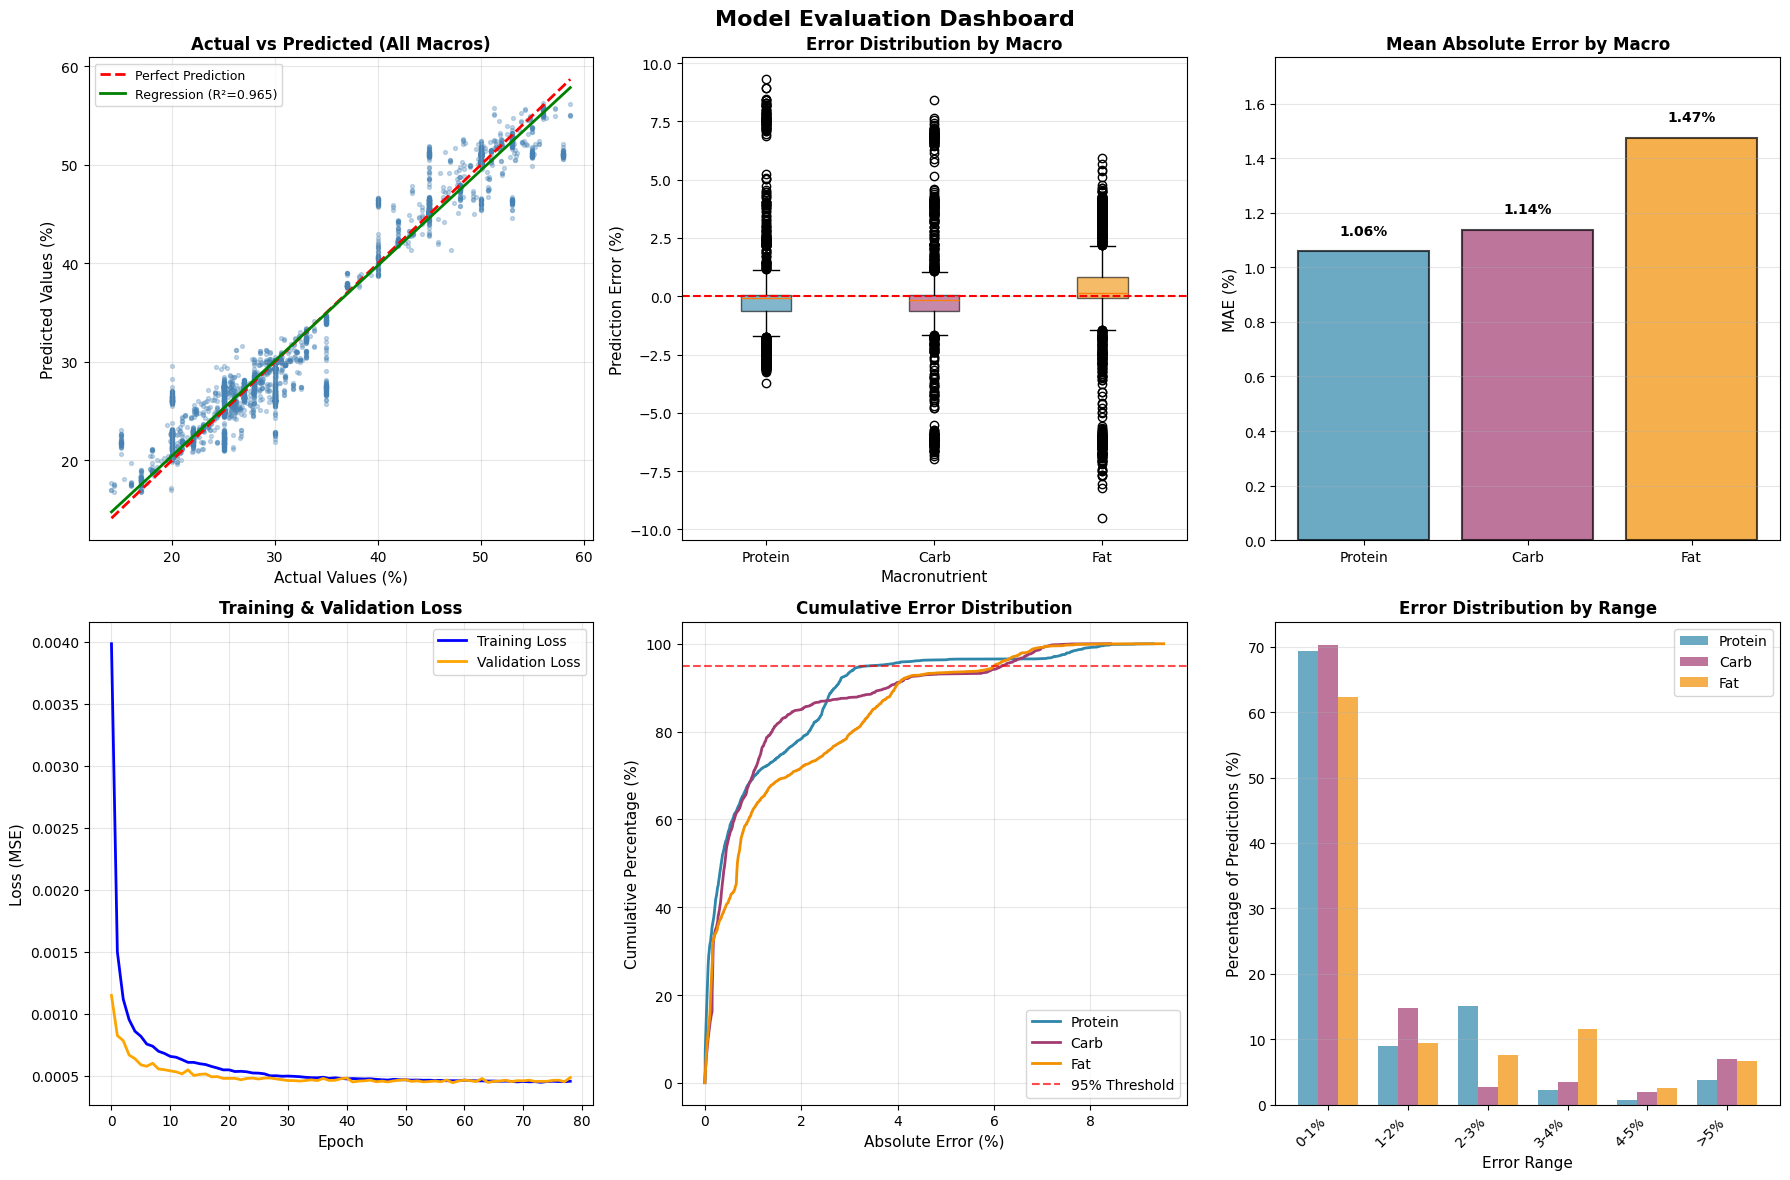

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from scipy import stats


def print_full_evaluation(y_true, y_pred, history):

    # Convert to percentages
    y_true_percent = y_true * 100
    y_pred_percent = y_pred * 100

    macro_names = ['Protein', 'Carb', 'Fat']
    results = {}

    print("\n" + "="*80)
    print(" " * 25 + "📊 MODEL EVALUATION REPORT")
    print("="*80)

    # ============================================
    # 1. DETAILED METRICS TABLE
    # ============================================
    print("\n📈 1. DETAILED METRICS PER MACRONUTRIENT")
    print("-"*80)
    print(f"{'Metric':<20} {'Protein':<15} {'Carb':<15} {'Fat':<15} {'Average':<12}")
    print("-"*80)

    all_mae = []
    all_rmse = []
    all_r2 = []
    all_mape = []

    for i, macro in enumerate(macro_names):
        y_true_macro = y_true_percent[:, i]
        y_pred_macro = y_pred_percent[:, i]

        # Calculate metrics
        mae = mean_absolute_error(y_true_macro, y_pred_macro)
        rmse = np.sqrt(mean_squared_error(y_true_macro, y_pred_macro))
        r2 = r2_score(y_true_macro, y_pred_macro)
        mape = np.mean(np.abs((y_true_macro - y_pred_macro) / (y_true_macro + 0.01))) * 100
        errors = y_true_macro - y_pred_macro
        ci_lower = np.percentile(errors, 2.5)
        ci_upper = np.percentile(errors, 97.5)

        results[macro] = {
            'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape,
            'CI_95': (ci_lower, ci_upper)
        }

        all_mae.append(mae)
        all_rmse.append(rmse)
        all_r2.append(r2)
        all_mape.append(mape)

    # Print table
    print(f"{'MAE (%)':<20} {results['Protein']['MAE']:<15.2f} {results['Carb']['MAE']:<15.2f} {results['Fat']['MAE']:<15.2f} {np.mean(all_mae):<12.2f}")
    print(f"{'RMSE (%)':<20} {results['Protein']['RMSE']:<15.2f} {results['Carb']['RMSE']:<15.2f} {results['Fat']['RMSE']:<15.2f} {np.mean(all_rmse):<12.2f}")
    print(f"{'R²':<20} {results['Protein']['R²']:<15.4f} {results['Carb']['R²']:<15.4f} {results['Fat']['R²']:<15.4f} {np.mean(all_r2):<12.4f}")
    print(f"{'MAPE (%)':<20} {results['Protein']['MAPE']:<15.1f} {results['Carb']['MAPE']:<15.1f} {results['Fat']['MAPE']:<15.1f} {np.mean(all_mape):<12.1f}")

    # ============================================
    # 2. 95% CONFIDENCE INTERVALS
    # ============================================
    print("\n📊 2. 95% CONFIDENCE INTERVALS (Error Distribution)")
    print("-"*80)
    for macro in macro_names:
        ci = results[macro]['CI_95']
        print(f"  {macro:<12}: [{ci[0]:>6.2f}%, {ci[1]:>6.2f}%]  (Prediction error range)")

    # ============================================
    # 3. OVERALL MODEL ASSESSMENT
    # ============================================
    print("\n🎯 3. OVERALL MODEL PERFORMANCE")
    print("-"*80)

    avg_mae = np.mean(all_mae)
    avg_rmse = np.mean(all_rmse)
    avg_r2 = np.mean(all_r2)

    print(f"  ✓ Average MAE  : {avg_mae:.2f}%  (The model is off by ~{avg_mae:.1f}% on average)")
    print(f"  ✓ Average RMSE : {avg_rmse:.2f}%  (Penalizes large errors)")
    print(f"  ✓ Average R²   : {avg_r2:.4f}   (Explains {avg_r2*100:.1f}% of variance)")

    # Quality assessment
    print("\n  ✅ Model Quality Assessment:")
    if avg_mae < 1.5:
        print("     ► MAE < 1.5% → EXCELLENT prediction accuracy")
    elif avg_mae < 3:
        print("     ► MAE < 3% → GOOD prediction accuracy")

    if avg_r2 > 0.95:
        print("     ► R² > 0.95 → EXCELLENT variance explanation")
    elif avg_r2 > 0.85:
        print("     ► R² > 0.85 → GOOD variance explanation")

    if avg_rmse / avg_mae < 1.5:
        print("     ► RMSE/MAE < 1.5 → No significant outliers")

    # ============================================
    # 4. TRAINING HISTORY ANALYSIS
    # ============================================
    if history:
        print("\n📉 4. TRAINING ANALYSIS")
        print("-"*80)

        final_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        best_epoch = np.argmin(history.history['val_loss']) + 1
        best_val_loss = np.min(history.history['val_loss'])

        print(f"  Final Training Loss   : {final_loss:.6f}")
        print(f"  Final Validation Loss : {final_val_loss:.6f}")
        print(f"  Best Epoch            : {best_epoch}")
        print(f"  Best Validation Loss  : {best_val_loss:.6f}")

        # Check overfitting
        overfitting_gap = final_val_loss - final_loss
        if overfitting_gap < 0.0005:
            print(f"\n  ✅ NO OVERFITTING detected (gap = {overfitting_gap:.6f})")
            print(f"     The model generalizes well to unseen data")
        elif overfitting_gap < 0.002:
            print(f"\n  ⚠️  MILD OVERFITTING detected (gap = {overfitting_gap:.6f})")
        else:
            print(f"\n  ❌ SIGNIFICANT OVERFITTING detected (gap = {overfitting_gap:.6f})")

    # ============================================
    # 5. ERROR STATISTICS
    # ============================================
    print("\n📐 5. ERROR STATISTICS (Absolute Errors)")
    print("-"*80)

    all_errors = []
    for i, macro in enumerate(macro_names):
        errors = np.abs(y_true_percent[:, i] - y_pred_percent[:, i])
        all_errors.extend(errors)

        print(f"\n  {macro}:")
        print(f"    ├─ Mean Error  : {np.mean(errors):.2f}%")
        print(f"    ├─ Std Dev     : {np.std(errors):.2f}%")
        print(f"    ├─ Median Error: {np.median(errors):.2f}%")
        print(f"    ├─ 90th Percentile: {np.percentile(errors, 90):.2f}%")
        print(f"    └─ 95th Percentile: {np.percentile(errors, 95):.2f}%")

    print(f"\n  Overall (All Macros Combined):")
    print(f"    ├─ Mean Error  : {np.mean(all_errors):.2f}%")
    print(f"    ├─ Std Dev     : {np.std(all_errors):.2f}%")
    print(f"    └─ Median Error: {np.median(all_errors):.2f}%")

    # ============================================
    # 6. SAMPLE PREDICTIONS (First 10 samples)
    # ============================================
    print("\n🔍 6. SAMPLE PREDICTIONS (First 10 test samples)")
    print("-"*80)
    print(f"{'Sample':<8} {'Actual P/C/F':<20} {'Predicted P/C/F':<20} {'Error P/C/F':<20}")
    print("-"*80)

    n_samples = min(10, len(y_true_percent))
    for i in range(n_samples):
        actual = f"{y_true_percent[i,0]:.0f}/{y_true_percent[i,1]:.0f}/{y_true_percent[i,2]:.0f}"
        pred = f"{y_pred_percent[i,0]:.0f}/{y_pred_percent[i,1]:.0f}/{y_pred_percent[i,2]:.0f}"
        error = f"{abs(y_true_percent[i,0]-y_pred_percent[i,0]):.1f}/{abs(y_true_percent[i,1]-y_pred_percent[i,1]):.1f}/{abs(y_true_percent[i,2]-y_pred_percent[i,2]):.1f}"
        print(f"{i+1:<8} {actual:<20} {pred:<20} {error:<20}")

    print("\n" + "="*80)
    print(" " * 25 + "✅ EVALUATION COMPLETE")
    print("="*80)

    return results


def plot_evaluation_graphs_inline(y_true, y_pred, history):

    y_true_percent = y_true * 100
    y_pred_percent = y_pred * 100

    macro_names = ['Protein', 'Carb', 'Fat']
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    # Create figure
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold', y=0.98)

    # ===== Plot 1: Actual vs Predicted =====
    ax1 = fig.add_subplot(2, 3, 1)
    all_actual = y_true_percent.flatten()
    all_pred = y_pred_percent.flatten()

    ax1.scatter(all_actual, all_pred, alpha=0.3, c='steelblue', s=8)
    min_val = min(all_actual.min(), all_pred.min())
    max_val = max(all_actual.max(), all_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    # Regression line
    z = np.polyfit(all_actual, all_pred, 1)
    p = np.poly1d(z)
    ax1.plot([min_val, max_val], [p(min_val), p(max_val)], 'g-', lw=2,
             label=f'Regression (R²={r2_score(all_actual, all_pred):.3f})')

    ax1.set_xlabel('Actual Values (%)', fontsize=11)
    ax1.set_ylabel('Predicted Values (%)', fontsize=11)
    ax1.set_title('Actual vs Predicted (All Macros)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # ===== Plot 2: Error Distribution =====
    ax2 = fig.add_subplot(2, 3, 2)
    errors_data = []
    for i in range(3):
        errors = y_true_percent[:, i] - y_pred_percent[:, i]
        errors_data.append(errors)

    bp = ax2.boxplot(errors_data, labels=macro_names, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Macronutrient', fontsize=11)
    ax2.set_ylabel('Prediction Error (%)', fontsize=11)
    ax2.set_title('Error Distribution by Macro', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # ===== Plot 3: MAE Comparison =====
    ax3 = fig.add_subplot(2, 3, 3)
    mae_values = []
    for i in range(3):
        mae = mean_absolute_error(y_true_percent[:, i], y_pred_percent[:, i])
        mae_values.append(mae)

    bars = ax3.bar(macro_names, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('MAE (%)', fontsize=11)
    ax3.set_title('Mean Absolute Error by Macro', fontsize=12, fontweight='bold')

    for bar, val in zip(bars, mae_values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
    ax3.set_ylim(0, max(mae_values) * 1.2)
    ax3.grid(True, alpha=0.3, axis='y')

    # ===== Plot 4: Training Curves =====
    ax4 = fig.add_subplot(2, 3, 4)
    if history:
        ax4.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
        ax4.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
        ax4.set_xlabel('Epoch', fontsize=11)
        ax4.set_ylabel('Loss (MSE)', fontsize=11)
        ax4.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

    # ===== Plot 5: Cumulative Error =====
    ax5 = fig.add_subplot(2, 3, 5)
    for i, macro in enumerate(macro_names):
        errors = np.abs(y_true_percent[:, i] - y_pred_percent[:, i])
        sorted_errors = np.sort(errors)
        cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
        ax5.plot(sorted_errors, cumulative, label=macro, linewidth=2, color=colors[i])

    ax5.set_xlabel('Absolute Error (%)', fontsize=11)
    ax5.set_ylabel('Cumulative Percentage (%)', fontsize=11)
    ax5.set_title('Cumulative Error Distribution', fontsize=12, fontweight='bold')
    ax5.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% Threshold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # ===== Plot 6: Error Heatmap by Range =====
    ax6 = fig.add_subplot(2, 3, 6)
    error_ranges = ['0-1%', '1-2%', '2-3%', '3-4%', '4-5%', '>5%']
    percentages = []

    for i in range(3):
        errors = np.abs(y_true_percent[:, i] - y_pred_percent[:, i])
        pct = []
        pct.append(np.sum(errors < 1) / len(errors) * 100)
        pct.append(np.sum((errors >= 1) & (errors < 2)) / len(errors) * 100)
        pct.append(np.sum((errors >= 2) & (errors < 3)) / len(errors) * 100)
        pct.append(np.sum((errors >= 3) & (errors < 4)) / len(errors) * 100)
        pct.append(np.sum((errors >= 4) & (errors < 5)) / len(errors) * 100)
        pct.append(np.sum(errors >= 5) / len(errors) * 100)
        percentages.append(pct)

    x = np.arange(len(error_ranges))
    width = 0.25

    for i, macro in enumerate(macro_names):
        ax6.bar(x + i*width, percentages[i], width, label=macro, color=colors[i], alpha=0.7)

    ax6.set_xlabel('Error Range', fontsize=11)
    ax6.set_ylabel('Percentage of Predictions (%)', fontsize=11)
    ax6.set_title('Error Distribution by Range', fontsize=12, fontweight='bold')
    ax6.set_xticks(x + width)
    ax6.set_xticklabels(error_ranges, rotation=45, ha='right')
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# # Run evaluation
results = print_full_evaluation(y_test, y_pred, history)

# # Plot graphs
plot_evaluation_graphs_inline(y_test, y_pred, history)



saving modle

In [ ]:
save_path = '/content/drive/MyDrive/graduation proj/nutrition_model/'
os.makedirs(save_path, exist_ok=True)

# حفظ الملفات
model.save(save_path + 'nutrition_model.h5')
joblib.dump(scaler, save_path + 'scaler.pkl')
joblib.dump(X.columns.tolist(), save_path + 'feature_columns.pkl')

print(f"done :{save_path}")

done :/content/drive/MyDrive/graduation proj/nutrition_model/


 Nutrition System

In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
import random

class AdvancedNutritionSystem:
    def __init__(self, model_path='/content/drive/MyDrive/graduation proj/nutrition_model/nutrition_model.h5',
                 scaler_path='/content/drive/MyDrive/graduation proj/nutrition_model/scaler.pkl',
                 features_path='/content/drive/MyDrive/graduation proj/nutrition_model/feature_columns.pkl'):

        self.create_healthy_food_database()

        # Load the model
        custom_objects = {
            'mse': MeanSquaredError(),
            'mean_squared_error': MeanSquaredError(),
        }

        try:
            print("🔄 Loading model...")
            self.model = load_model(model_path, custom_objects=custom_objects, compile=False)
            self.model.compile(optimizer='adam', loss='mse', metrics=['mae'])
            print("✅ Model loaded successfully")
        except Exception as e:
            print(f"⚠️ Error loading model: {e}")
            print("⚠️ Using rule-based macro calculation instead")
            self.model = None

        # Load remaining files
        try:
            self.scaler = joblib.load(scaler_path)
            self.feature_columns = joblib.load(features_path)
        except:
            print("⚠️ Scaler or features not found, using rule-based system")
            self.scaler = None
            self.feature_columns = None

        # BMI constants
        self.BMI_CATEGORIES = {
            (0, 18.5): 'Underweight',
            (18.5, 25): 'Normal',
            (25, 30): 'Overweight',
            (30, 40): 'Obese',
            (40, float('inf')): 'Extremely_Obese'
        }

    def create_healthy_food_database(self):
        """Create healthy food database from scratch"""

        self.food_db = pd.DataFrame([
            {'ingr_name': 'chicken breast', 'category': 'Protein', 'cal/g': 1.65, 'protein(g)': 0.31, 'carb(g)': 0.00, 'fat(g)': 0.036},
            {'ingr_name': 'grilled chicken', 'category': 'Protein', 'cal/g': 1.65, 'protein(g)': 0.31, 'carb(g)': 0.00, 'fat(g)': 0.036},
            {'ingr_name': 'turkey breast', 'category': 'Protein', 'cal/g': 1.35, 'protein(g)': 0.30, 'carb(g)': 0.00, 'fat(g)': 0.02},
            {'ingr_name': 'lean beef', 'category': 'Protein', 'cal/g': 2.0, 'protein(g)': 0.26, 'carb(g)': 0.00, 'fat(g)': 0.10},
            {'ingr_name': 'salmon', 'category': 'Protein', 'cal/g': 2.08, 'protein(g)': 0.20, 'carb(g)': 0.00, 'fat(g)': 0.13},
            {'ingr_name': 'tuna', 'category': 'Protein', 'cal/g': 1.3, 'protein(g)': 0.29, 'carb(g)': 0.00, 'fat(g)': 0.01},
            {'ingr_name': 'tilapia', 'category': 'Protein', 'cal/g': 1.28, 'protein(g)': 0.26, 'carb(g)': 0.00, 'fat(g)': 0.027},
            {'ingr_name': 'cod', 'category': 'Protein', 'cal/g': 0.85, 'protein(g)': 0.19, 'carb(g)': 0.00, 'fat(g)': 0.005},
            {'ingr_name': 'eggs', 'category': 'Protein', 'cal/g': 1.55, 'protein(g)': 0.125, 'carb(g)': 0.012, 'fat(g)': 0.105},
            {'ingr_name': 'egg whites', 'category': 'Protein', 'cal/g': 0.52, 'protein(g)': 0.11, 'carb(g)': 0.007, 'fat(g)': 0.002},
            {'ingr_name': 'greek yogurt', 'category': 'Protein', 'cal/g': 0.59, 'protein(g)': 0.10, 'carb(g)': 0.036, 'fat(g)': 0.004},
            {'ingr_name': 'cottage cheese', 'category': 'Protein', 'cal/g': 0.98, 'protein(g)': 0.11, 'carb(g)': 0.034, 'fat(g)': 0.043},
            {'ingr_name': 'tofu', 'category': 'Protein', 'cal/g': 0.76, 'protein(g)': 0.08, 'carb(g)': 0.019, 'fat(g)': 0.048},

            {'ingr_name': 'brown rice', 'category': 'Carb', 'cal/g': 1.11, 'protein(g)': 0.026, 'carb(g)': 0.23, 'fat(g)': 0.009},
            {'ingr_name': 'quinoa', 'category': 'Carb', 'cal/g': 1.20, 'protein(g)': 0.044, 'carb(g)': 0.21, 'fat(g)': 0.019},
            {'ingr_name': 'oats', 'category': 'Carb', 'cal/g': 3.89, 'protein(g)': 0.169, 'carb(g)': 0.66, 'fat(g)': 0.069},
            {'ingr_name': 'whole wheat bread', 'category': 'Carb', 'cal/g': 2.47, 'protein(g)': 0.13, 'carb(g)': 0.42, 'fat(g)': 0.033},
            {'ingr_name': 'sweet potato', 'category': 'Carb', 'cal/g': 0.86, 'protein(g)': 0.016, 'carb(g)': 0.20, 'fat(g)': 0.001},
            {'ingr_name': 'potato', 'category': 'Carb', 'cal/g': 0.77, 'protein(g)': 0.02, 'carb(g)': 0.17, 'fat(g)': 0.001},
            {'ingr_name': 'whole wheat pasta', 'category': 'Carb', 'cal/g': 1.24, 'protein(g)': 0.05, 'carb(g)': 0.25, 'fat(g)': 0.01},
            {'ingr_name': 'lentils', 'category': 'Carb', 'cal/g': 1.16, 'protein(g)': 0.09, 'carb(g)': 0.20, 'fat(g)': 0.004},
            {'ingr_name': 'chickpeas', 'category': 'Carb', 'cal/g': 1.39, 'protein(g)': 0.08, 'carb(g)': 0.23, 'fat(g)': 0.026},
            {'ingr_name': 'black beans', 'category': 'Carb', 'cal/g': 1.32, 'protein(g)': 0.09, 'carb(g)': 0.24, 'fat(g)': 0.005},

            {'ingr_name': 'banana', 'category': 'Carb', 'cal/g': 0.89, 'protein(g)': 0.011, 'carb(g)': 0.23, 'fat(g)': 0.003},
            {'ingr_name': 'apple', 'category': 'Carb', 'cal/g': 0.52, 'protein(g)': 0.003, 'carb(g)': 0.14, 'fat(g)': 0.002},
            {'ingr_name': 'berries', 'category': 'Carb', 'cal/g': 0.57, 'protein(g)': 0.007, 'carb(g)': 0.14, 'fat(g)': 0.003},
            {'ingr_name': 'orange', 'category': 'Carb', 'cal/g': 0.47, 'protein(g)': 0.009, 'carb(g)': 0.12, 'fat(g)': 0.001},

            {'ingr_name': 'broccoli', 'category': 'Vegetable', 'cal/g': 0.35, 'protein(g)': 0.024, 'carb(g)': 0.07, 'fat(g)': 0.004},
            {'ingr_name': 'spinach', 'category': 'Vegetable', 'cal/g': 0.23, 'protein(g)': 0.029, 'carb(g)': 0.036, 'fat(g)': 0.004},
            {'ingr_name': 'kale', 'category': 'Vegetable', 'cal/g': 0.49, 'protein(g)': 0.043, 'carb(g)': 0.09, 'fat(g)': 0.007},
            {'ingr_name': 'asparagus', 'category': 'Vegetable', 'cal/g': 0.20, 'protein(g)': 0.022, 'carb(g)': 0.039, 'fat(g)': 0.001},
            {'ingr_name': 'cauliflower', 'category': 'Vegetable', 'cal/g': 0.25, 'protein(g)': 0.019, 'carb(g)': 0.05, 'fat(g)': 0.003},
            {'ingr_name': 'zucchini', 'category': 'Vegetable', 'cal/g': 0.17, 'protein(g)': 0.012, 'carb(g)': 0.031, 'fat(g)': 0.004},
            {'ingr_name': 'bell peppers', 'category': 'Vegetable', 'cal/g': 0.26, 'protein(g)': 0.01, 'carb(g)': 0.06, 'fat(g)': 0.003},
            {'ingr_name': 'tomatoes', 'category': 'Vegetable', 'cal/g': 0.18, 'protein(g)': 0.009, 'carb(g)': 0.039, 'fat(g)': 0.002},
            {'ingr_name': 'cucumber', 'category': 'Vegetable', 'cal/g': 0.15, 'protein(g)': 0.007, 'carb(g)': 0.036, 'fat(g)': 0.001},
            {'ingr_name': 'carrots', 'category': 'Vegetable', 'cal/g': 0.41, 'protein(g)': 0.009, 'carb(g)': 0.10, 'fat(g)': 0.002},

            {'ingr_name': 'avocado', 'category': 'Fat', 'cal/g': 1.60, 'protein(g)': 0.02, 'carb(g)': 0.09, 'fat(g)': 0.15},
            {'ingr_name': 'olive oil', 'category': 'Fat', 'cal/g': 8.84, 'protein(g)': 0.00, 'carb(g)': 0.00, 'fat(g)': 1.00},
            {'ingr_name': 'almonds', 'category': 'Fat', 'cal/g': 5.78, 'protein(g)': 0.21, 'carb(g)': 0.22, 'fat(g)': 0.50},
            {'ingr_name': 'walnuts', 'category': 'Fat', 'cal/g': 6.54, 'protein(g)': 0.15, 'carb(g)': 0.14, 'fat(g)': 0.65},

            {'ingr_name': 'water', 'category': 'Drink', 'cal/g': 0.0, 'protein(g)': 0.0, 'carb(g)': 0.0, 'fat(g)': 0.0},
            {'ingr_name': 'green tea', 'category': 'Drink', 'cal/g': 0.01, 'protein(g)': 0.0, 'carb(g)': 0.0, 'fat(g)': 0.0},
        ])

        self.protein_foods = self.food_db[self.food_db['category'] == 'Protein']
        self.carb_foods = self.food_db[self.food_db['category'] == 'Carb']
        self.veg_foods = self.food_db[self.food_db['category'] == 'Vegetable']
        self.fat_foods = self.food_db[self.food_db['category'] == 'Fat']
        self.drink_foods = self.food_db[self.food_db['category'] == 'Drink']

    def predict_macros(self, user_data):
        """Predict macro percentages for user"""

        # Rule-based system (more reliable)
        goal = user_data.get('goal', 'Maintenance')
        sport = user_data.get('sport_type', 'None')
        bmi = user_data.get('BMI', 22)

        if sport == 'Football':
            protein = 25
            carbs = 55
            fat = 20
        elif goal == 'Fat_Loss':
            protein = 32 if bmi > 25 else 30
            carbs = 38 if bmi > 25 else 40
            fat = 30
        elif goal == 'Muscle_Gain':
            protein = 32
            carbs = 45
            fat = 23
        else:  # Maintenance
            protein = 28
            carbs = 45
            fat = 27

        # Adjust for medical conditions
        if user_data.get('anemia', 0) == 1:
            protein += 3
            carbs -= 2

        if user_data.get('diabetes', 0) == 1:
            carbs = min(carbs, 42)
            protein += 2

        # Ensure total is 100
        total = protein + carbs + fat
        if total != 100:
            protein += (100 - total)

        return {
            'protein': protein,
            'carbs': carbs,
            'fat': fat
        }

    def calculate_meal_needs(self, total_calories, macros_percent, num_meals=3):
        """Calculate each meal's requirements"""

        meal_distribution = [0.25, 0.40, 0.35]

        meal_needs = []
        for i, dist in enumerate(meal_distribution[:num_meals]):
            calories_per_meal = total_calories * dist

            meal = {
                'calories': calories_per_meal,
                'protein_g': (calories_per_meal * (macros_percent['protein']/100)) / 4,
                'carbs_g': (calories_per_meal * (macros_percent['carbs']/100)) / 4,
                'fat_g': (calories_per_meal * (macros_percent['fat']/100)) / 9
            }
            meal_needs.append(meal)

        return meal_needs

    def recommend_meal_from_db(self, target_protein, target_carbs, target_fat,
                                target_calories, meal_type='main', user_data=None):
        """Compose a healthy meal from the clean database"""

        meal_foods = []
        current_calories = 0
        current_protein = 0
        current_carbs = 0
        current_fat = 0

        if meal_type == 'Breakfast':
            protein_ratio = 0.25
            carb_ratio = 0.50
            fat_ratio = 0.25
        elif meal_type == 'Lunch':
            protein_ratio = 0.35
            carb_ratio = 0.40
            fat_ratio = 0.25
        else:  # Dinner
            protein_ratio = 0.35
            carb_ratio = 0.35
            fat_ratio = 0.30

        meal_protein_needed = target_protein * protein_ratio
        meal_carbs_needed = target_carbs * carb_ratio

        if len(self.protein_foods) > 0:
            protein_source = self.protein_foods.sample(1).iloc[0]
            protein_amount = min(180, max(80, meal_protein_needed * 1.5))

            meal_foods.append({
                'name': protein_source['ingr_name'],
                'amount_g': round(protein_amount, 1),
                'calories': protein_amount * protein_source['cal/g'],
                'protein': protein_amount * protein_source['protein(g)'],
                'carbs': protein_amount * protein_source['carb(g)'],
                'fat': protein_amount * protein_source['fat(g)']
            })

            current_calories += meal_foods[-1]['calories']
            current_protein += meal_foods[-1]['protein']
            current_carbs += meal_foods[-1]['carbs']
            current_fat += meal_foods[-1]['fat']

        if len(self.carb_foods) > 0:
            carb_source = self.carb_foods.sample(1).iloc[0]
            carb_amount = min(250, max(100, meal_carbs_needed * 1.3))

            meal_foods.append({
                'name': carb_source['ingr_name'],
                'amount_g': round(carb_amount, 1),
                'calories': carb_amount * carb_source['cal/g'],
                'protein': carb_amount * carb_source['protein(g)'],
                'carbs': carb_amount * carb_source['carb(g)'],
                'fat': carb_amount * carb_source['fat(g)']
            })

            current_calories += meal_foods[-1]['calories']
            current_protein += meal_foods[-1]['protein']
            current_carbs += meal_foods[-1]['carbs']
            current_fat += meal_foods[-1]['fat']

        if len(self.veg_foods) > 0:
            veg = self.veg_foods.sample(1).iloc[0]
            veg_amount = 120

            meal_foods.append({
                'name': veg['ingr_name'],
                'amount_g': veg_amount,
                'calories': veg_amount * veg['cal/g'],
                'protein': veg_amount * veg['protein(g)'],
                'carbs': veg_amount * veg['carb(g)'],
                'fat': veg_amount * veg['fat(g)']
            })

            current_calories += meal_foods[-1]['calories']
            current_protein += meal_foods[-1]['protein']
            current_carbs += meal_foods[-1]['carbs']
            current_fat += meal_foods[-1]['fat']

        # 4. إضافة دهون صحية إذا كانت قليلة
        if current_fat < target_fat * 0.5 and len(self.fat_foods) > 0:
            fat_source = self.fat_foods.sample(1).iloc[0]
            fat_amount = min(30, max(10, (target_fat - current_fat) * 0.8))

            if fat_amount > 5:
                meal_foods.append({
                    'name': fat_source['ingr_name'],
                    'amount_g': round(fat_amount, 1),
                    'calories': fat_amount * fat_source['cal/g'],
                    'protein': fat_amount * fat_source['protein(g)'],
                    'carbs': fat_amount * fat_source['carb(g)'],
                    'fat': fat_amount * fat_source['fat(g)']
                })

                current_calories += meal_foods[-1]['calories']
                current_protein += meal_foods[-1]['protein']
                current_carbs += meal_foods[-1]['carbs']
                current_fat += meal_foods[-1]['fat']

        return {
            'foods': meal_foods,
            'totals': {
                'calories': round(current_calories, 1),
                'protein': round(current_protein, 1),
                'carbs': round(current_carbs, 1),
                'fat': round(current_fat, 1)
            },
            'targets': {
                'calories': target_calories,
                'protein': target_protein,
                'carbs': target_carbs,
                'fat': target_fat
            }
        }

    def generate_daily_plan(self, user_data, total_calories):
        """Generate complete daily plan"""
        macros = self.predict_macros(user_data)
        meal_needs = self.calculate_meal_needs(total_calories, macros, num_meals=3)

        print(f"\n📊 Target macros: Protein {macros['protein']:.0f}% | Carbs {macros['carbs']:.0f}% | Fat {macros['fat']:.0f}%")
        print(f"🎯 {total_calories} calories/day")
        print(f"🥩 Target protein: {(total_calories * macros['protein']/100)/4:.0f}g")

        plan = {
            'user_info': user_data,
            'daily_macros': macros,
            'meals': []
        }

        meal_types = ['Breakfast', 'Lunch', 'Dinner']
        for i, needs in enumerate(meal_needs):
            meal = self.recommend_meal_from_db(
                needs['protein_g'],
                needs['carbs_g'],
                needs['fat_g'],
                needs['calories'],
                meal_types[i],
                user_data
            )
            plan['meals'].append({
                'name': meal_types[i],
                'foods': meal['foods'],
                'totals': meal['totals']
            })

        return plan

    def generate_weekly_plan(self, user_data, total_calories):
        """Generate complete weekly meal plan (7 days)"""

        macros = self.predict_macros(user_data)
        daily_meal_needs = self.calculate_meal_needs(total_calories, macros, num_meals=3)

        weekly_plan = {
            'user_info': user_data,
            'daily_macros': macros,
            'days': []
        }

        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        meal_types = ['Breakfast', 'Lunch', 'Dinner']

        for day in days:
            day_meals = []

            for i, needs in enumerate(daily_meal_needs):
                # Add variety by changing random seed
                random.seed(hash(day + meal_types[i]) % 2**32)

                meal = self.recommend_meal_from_db(
                    needs['protein_g'],
                    needs['carbs_g'],
                    needs['fat_g'],
                    needs['calories'],
                    meal_types[i],
                    user_data
                )
                day_meals.append({
                    'name': meal_types[i],
                    'foods': meal['foods'],
                    'totals': meal['totals']
                })

            weekly_plan['days'].append({
                'day': day,
                'meals': day_meals
            })

        return weekly_plan

    def print_weekly_plan(self, weekly_plan):
        """Print formatted weekly plan"""

        print("\n" + "="*80)
        print("📅 Your Weekly Meal Plan:")
        print("="*80)

        m = weekly_plan['daily_macros']
        print(f"\n📊 Daily macro percentages: Protein {m['protein']:.1f}% | Carbs {m['carbs']:.1f}% | Fat {m['fat']:.1f}%")

        # Calculate approximate daily calories
        if weekly_plan['days'][0]['meals']:
            daily_cals = sum(meal['totals']['calories'] for meal in weekly_plan['days'][0]['meals'])
            print(f"🔥 Target daily calories: ~{daily_cals:.0f} calories")

        for day_data in weekly_plan['days']:
            print(f"\n{'='*60}")
            print(f"📆 {day_data['day']}:")
            print(f"{'='*60}")

            total_day_calories = 0
            total_day_protein = 0
            total_day_carbs = 0
            total_day_fat = 0

            for meal in day_data['meals']:
                print(f"\n  🍽️ {meal['name']}:")
                for food in meal['foods']:
                    print(f"      • {food['name']}: {food['amount_g']:.0f} grams")
                print(f"      📊 Calories: {meal['totals']['calories']:.0f}")
                print(f"      💪 Protein: {meal['totals']['protein']:.0f}g")
                print(f"      🍚 Carbs: {meal['totals']['carbs']:.0f}g")
                print(f"      🥑 Fat: {meal['totals']['fat']:.0f}g")

                total_day_calories += meal['totals']['calories']
                total_day_protein += meal['totals']['protein']
                total_day_carbs += meal['totals']['carbs']
                total_day_fat += meal['totals']['fat']

            print(f"\n  📊 Daily total: {total_day_calories:.0f} calories | Protein {total_day_protein:.0f}g | Carbs {total_day_carbs:.0f}g | Fat {total_day_fat:.0f}g")

        print("\n" + "="*80)
        print("✅ Healthy and varied week! Different meals every day 🥗")
        print("="*80)

Exercise Planner

In [ ]:
import pandas as pd
import numpy as np
import random
import json
from typing import Dict, List, Tuple

# -----------------------------------------------
# Integrated Exercise System
# -----------------------------------------------
class ExercisePlanner:
    def __init__(self):
        # Define exercises
        self.exercise_rules = {
            "gym": {
                "bench_press": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 150, "down_threshold": 80, "min_angle": 70, "max_angle": 160},
                "shoulder_press": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 160, "down_threshold": 90, "min_angle": 80, "max_angle": 170},
                "lat_pulldown": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 150, "down_threshold": 60, "min_angle": 45, "max_angle": 160},
                "bicep_curl": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 40, "down_threshold": 150, "min_angle": 30, "max_angle": 160},
                "triceps_pushdown": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 160, "down_threshold": 40, "min_angle": 30, "max_angle": 170},
                "leg_extension": {"joints": ["knee_left", "knee_right"], "up_threshold": 160, "down_threshold": 100, "min_angle": 90, "max_angle": 175}
            },
            "rehab": {
                "arm_abduction": {"joints": ["shoulder_abduction_left", "shoulder_abduction_right"], "up_threshold": 80, "down_threshold": 20, "min_angle": 15, "max_angle": 95},
                "shoulder_flexion": {"joints": ["shoulder_flexion_left", "shoulder_flexion_right"], "up_threshold": 90, "down_threshold": 10, "min_angle": 0, "max_angle": 180},
                "arm_vw": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 120, "down_threshold": 60, "min_angle": 45, "max_angle": 135},
                "pushups": {"joints": ["elbow_left", "elbow_right"], "up_threshold": 160, "down_threshold": 80, "min_angle": 70, "max_angle": 170},
                "leg_abduction": {"joints": ["hip_left", "hip_right"], "up_threshold": 40, "down_threshold": 10, "min_angle": 0, "max_angle": 45},
                "squats": {"joints": ["knee_left", "knee_right"], "up_threshold": 160, "down_threshold": 80, "min_angle": 70, "max_angle": 170},
                "leg_lunge": {"joints": ["knee_left", "knee_right"], "up_threshold": 160, "down_threshold": 95, "min_angle": 85, "max_angle": 170}
            },
            "fitness": {
                "bodyweight_squats": {"joints": ["knee_left", "knee_right"], "up_threshold": 120, "down_threshold": 60, "min_angle": 40, "max_angle": 130},
                "jumping_jacks": {"joints": ["shoulder_abduction_left", "shoulder_abduction_right"], "up_threshold": 140, "down_threshold": 30, "min_angle": 20, "max_angle": 150},
                "lunge": {"joints": ["knee_left", "knee_right"], "up_threshold": 160, "down_threshold": 95, "min_angle": 85, "max_angle": 170},
                "leg_swing": {"joints": ["hip_left", "hip_right"], "up_threshold": 80, "down_threshold": 10, "min_angle": 0, "max_angle": 90},
                "butt_kicks": {"joints": ["knee_left", "knee_right"], "up_threshold": 60, "down_threshold": 150, "min_angle": 45, "max_angle": 160},
                "high_knee": {"joints": ["hip_left", "hip_right"], "up_threshold": 80, "down_threshold": 160, "min_angle": 70, "max_angle": 170},
                "arm_circles": {
                    "joints": ["shoulder_left", "shoulder_right"],
                    "up_threshold": 90,
                    "down_threshold": 180,
                    "min_angle": 30,
                    "max_angle": 180,
                    "special_function": "arm_circle"
                },
                "arm_half_circles": {
                    "joints": ["shoulder_left", "shoulder_right"],
                    "up_threshold": 80,
                    "down_threshold": 120,
                    "min_angle": 30,
                    "max_angle": 120,
                    "special_function": "arm_circle"
                }
            }
        }

        # Classify exercises
        self.exercise_categories = self.categorize_exercises()

    def categorize_exercises(self):
        """Classify exercises by type and target muscles"""
        categories = {
            'Upper_Body': [],
            'Lower_Body': [],
            'Core': [],
            'Cardio': [],
            'Full_Body': []
        }

        for category, exercises in self.exercise_rules.items():
            for ex_name, ex_data in exercises.items():
                # Determine exercise type based on joints
                joints = ex_data['joints']
                if any('knee' in j or 'hip' in j for j in joints):
                    if any('shoulder' in j or 'elbow' in j for j in joints):
                        categories['Full_Body'].append({
                            'name': ex_name,
                            'category': category,
                            'rules': ex_data
                        })
                    else:
                        categories['Lower_Body'].append({
                            'name': ex_name,
                            'category': category,
                            'rules': ex_data
                        })
                elif any('shoulder' in j or 'elbow' in j for j in joints):
                    categories['Upper_Body'].append({
                        'name': ex_name,
                        'category': category,
                        'rules': ex_data
                    })
                else:
                    categories['Cardio'].append({
                        'name': ex_name,
                        'category': category,
                        'rules': ex_data
                    })

        return categories

    def select_exercises_by_goal(self, goal: str, available_days: int = 4, injuries: Dict = None) -> Dict:
        """Select appropriate exercises based on goal considering injuries"""

        exercise_plan = {
            'weekly_schedule': [],
            'exercise_details': {},
            'total_weekly_volume': 0,
            'tips': []
        }

        # Determine exercise distribution based on goal
        if goal == 'Muscle_Gain':
            distribution = {
                'Upper_Body': 0.4,
                'Lower_Body': 0.3,
                'Full_Body': 0.2,
                'Core': 0.1
            }
            sets_per_exercise = 4
            reps_range = "8-12"
            rest_time = "90 sec"
            exercise_plan['tips'] = [
                'Focus on gradually increasing weights',
                'Take adequate rest between sets',
                'Eat enough protein within 2 hours of workout'
            ]

        elif goal == 'Fat_Loss':
            distribution = {
                'Cardio': 0.4,
                'Full_Body': 0.3,
                'Upper_Body': 0.15,
                'Lower_Body': 0.15
            }
            sets_per_exercise = 3
            reps_range = "15-20"
            rest_time = "45 sec"
            exercise_plan['tips'] = [
                'Maintain high heart rate',
                'Reduce rest periods between exercises',
                'Drink enough water before and during workout'
            ]

        else:  # Maintenance
            distribution = {
                'Full_Body': 0.3,
                'Upper_Body': 0.25,
                'Lower_Body': 0.25,
                'Core': 0.1,
                'Cardio': 0.1
            }
            sets_per_exercise = 3
            reps_range = "12-15"
            rest_time = "60 sec"
            exercise_plan['tips'] = [
                'Mix between strength and cardio exercises',
                'Listen to your body and rest when needed',
                'Maintain consistent performance'
            ]

        # Add injury tips
        if injuries:
            if injuries.get('back_pain', 0) == 1:
                exercise_plan['tips'].append('Avoid exercises that strain the back')
                # Reduce Lower_Body exercises
                distribution['Lower_Body'] = distribution.get('Lower_Body', 0) * 0.5
                distribution['Upper_Body'] = distribution.get('Upper_Body', 0) + 0.1
            if injuries.get('ankle_injury', 0) == 1:
                exercise_plan['tips'].append('Use low-impact exercises for ankles')
                # Reduce high-impact cardio
                distribution['Cardio'] = distribution.get('Cardio', 0) * 0.7

        # Select exercises for each day
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

        selected_days = random.sample(days, min(available_days, len(days)))
        selected_days.sort(key=lambda x: days.index(x))

        for day in selected_days:
            day_exercises = []

            # Select 4-6 exercises per day
            num_exercises = min(random.randint(4, 6), available_days * 2)

            for _ in range(num_exercises):
                # Select exercise type based on distribution
                exercise_type = random.choices(
                    list(distribution.keys()),
                    weights=list(distribution.values())
                )[0]

                # Select specific exercise from category
                if self.exercise_categories[exercise_type]:
                    exercise = random.choice(self.exercise_categories[exercise_type])

                    # Avoid repeating the same exercise on the same day
                    if any(ex['name'] == exercise['name'] for ex in day_exercises):
                        continue

                    # Add exercise details
                    exercise_detail = {
                        'name': exercise['name'].replace('_', ' ').title(),
                        'type': exercise_type,
                        'category': exercise['category'],
                        'sets': sets_per_exercise,
                        'reps': reps_range,
                        'rest': rest_time,
                        'joints': exercise['rules']['joints']
                    }

                    day_exercises.append(exercise_detail)

                    # Store complete details
                    if exercise['name'] not in exercise_plan['exercise_details']:
                        exercise_plan['exercise_details'][exercise['name']] = {
                            'rules': exercise['rules'],
                            'total_volume_sets': 0
                        }
                    exercise_plan['exercise_details'][exercise['name']]['total_volume_sets'] += sets_per_exercise

            exercise_plan['weekly_schedule'].append({
                'day': day,
                'exercises': day_exercises[:min(6, len(day_exercises))],  # Maximum 6 exercises
                'total_exercises': min(6, len(day_exercises))
            })

        # Calculate total volume
        exercise_plan['total_weekly_volume'] = sum(
            len(day['exercises']) for day in exercise_plan['weekly_schedule']
        )

        return exercise_plan
    def create_workout_plan(self, goal: str, activity_level: str, injuries: Dict = None) -> Dict:
        """
        Create workout plan based on goal and activity level
        """
        # تحويل مستوى النشاط إلى عدد أيام التمرين
        days_map = {
            'Sedentary': 3,
            'Light': 3,
            'Moderate': 4,
            'Active': 5,
            'Athlete': 6
        }

        available_days = days_map.get(activity_level, 4)

        # استدعاء الدالة الموجودة
        return self.select_exercises_by_goal(
            goal=goal,
            available_days=available_days,
            injuries=injuries or {}
        )
    def print_workout_plan(self, plan: Dict):
        """Print formatted workout plan"""
        print("\n" + "="*70)
        print("💪 Weekly Workout Plan:")
        print("="*70)

        for workout in plan['weekly_schedule']:
            print(f"\n📅 {workout['day']}:")
            print("-" * 40)
            for ex in workout['exercises']:
                print(f"  • {ex['name']}")
                print(f"    {ex['sets']} sets × {ex['reps']} (rest {ex['rest']})")
                print(f"    Joints: {', '.join(set([j.replace('_', ' ').title() for j in ex['joints']]))}")

        print("\n💡 Exercise Tips:")
        for tip in plan['tips']:
            print(f"  • {tip}")

In [ ]:
# -----------------------------------------------
# Final Integrated System
# -----------------------------------------------
class IntegratedHealthSystem:
    def __init__(self):
        self.nutrition = AdvancedNutritionSystem()
        self.exercise = ExercisePlanner()

    def get_complete_plan(self, user_data, daily_calories):
        """Get complete plan (food + exercises)"""

        print("🔄 Analyzing your data...")

        # Nutrition plan
        nutrition_plan = self.nutrition.generate_daily_plan(user_data, daily_calories)

        # Exercise plan
        workout_plan = self.exercise.create_workout_plan(  # المشكلة هنا
        user_data['goal'],
        user_data['activity_level']
    )

        return {
            'nutrition': nutrition_plan,
            'workout': workout_plan
        }

testing

In [ ]:
# -----------------------------------------------
# Fixed User Data (instead of input)
# -----------------------------------------------
def get_fixed_user_data():
    """
    Fixed user data in code for quick testing
    """

    user_data = {
        # Basic Info
        'age': 23,
        'gender': 'Female',
        'height_cm': 166,
        'weight_kg': 68,

        # Activity
        'job': 'Student',
        'activity_level': 'Moderate',
        'goal': 'Fat_Loss',
        'water_intake_liters': 1.0,
        'surgery_type': 'Spinal Surgery',

        # Sport
        'sport_type': 'None',
        'experience_level': 'Beginner',
        'training_days_per_week': 0,
        'training_duration_min': 0,

        # Injuries
        'ankle_injury': 0,
        'back_pain': 0,
        'muscle_tear': 0,

        # Meals
        'meals_per_day': 3,
        'has_snacks': 2,

        # Allergies
        'nut_allergy': 0,
        'dairy_allergy': 0,
        'gluten_intolerance': 0,
        'shellfish_allergy': 0,
        'egg_allergy': 0,

        # Diseases
        'diabetes': 0,
        'hypertension': 0,
        'kidney_disease': 0,
        'heart_disease': 0,
        'pcos': 0,
        'anemia': 1,
        'gout': 0
    }

    return user_data


# -----------------------------------------------
# Simplified main (without any inputs)
# -----------------------------------------------
def main():
    user_data = get_fixed_user_data()
    injuries = {
        'ankle_injury': user_data['ankle_injury'],
        'back_pain': user_data['back_pain'],
        'muscle_tear': user_data['muscle_tear']
    }

    # ------------------------- Calculate indicators -------------------------
    height_m = user_data['height_cm'] / 100
    user_data['BMI'] = round(user_data['weight_kg'] / (height_m ** 2), 1)

    if user_data['gender'] == 'Male':
        bmr = (10 * user_data['weight_kg'] + 6.25 * user_data['height_cm'] - 5 * user_data['age'] + 5)
    else:
        bmr = (10 * user_data['weight_kg'] + 6.25 * user_data['height_cm'] - 5 * user_data['age'] - 161)
    user_data['BMR'] = round(bmr, 0)

    activity_multiplier = {
        'Sedentary': 1.2, 'Light': 1.375, 'Moderate': 1.55,
        'Active': 1.725, 'Athlete': 1.9
    }
    user_data['TDEE'] = round(user_data['BMR'] * activity_multiplier[user_data['activity_level']], 0)

    base_cals = user_data['TDEE']
    if user_data['goal'] == 'Fat_Loss':
        base_cals -= 500
    elif user_data['goal'] == 'Muscle_Gain':
        base_cals += 400
    user_data['Adjusted_Calories'] = max(int(base_cals), 1400)

    # Display summary
    print("\n" + "="*70)
    print("📊 Your Data Summary:")
    print("="*70)
    print(f"📏 BMI: {user_data['BMI']}")
    print(f"🔥 BMR: {user_data['BMR']} calories")
    print(f"⚡ TDEE: {user_data['TDEE']} calories")
    print(f"🎯 Adjusted Calories: {user_data['Adjusted_Calories']} calories")

    # Prepare data for model
    model_input = {
        'age': user_data['age'],
        'gender': user_data['gender'],
        'BMI': user_data['BMI'],
        'sport_type': user_data['sport_type'],
        'goal': user_data['goal'],
        'activity_level': user_data['activity_level'],
        'surgery_type': user_data['surgery_type'],
        'diabetes': user_data['diabetes'],
        'hypertension': user_data['hypertension'],
        'kidney_disease': user_data['kidney_disease'],
        'heart_disease': user_data['heart_disease'],
        'pcos': user_data['pcos'],
        'anemia': user_data['anemia'],
        'gout': user_data['gout']
    }

    # Create integrated system
    print("\n🔄 Creating your integrated health plan...")

    try:
        system = IntegratedHealthSystem()
        complete_plan = system.get_complete_plan(model_input, user_data['Adjusted_Calories'])

        # Display plan (as is)
        print("\n" + "="*70)
        print("📋 Your Personalized Plan:")
        print("="*70)

        # Nutrition section
        print("\n🥗 **Nutrition:**")
        print("-" * 40)

        m = complete_plan['nutrition']['daily_macros']
        print(f"📊 Macro percentages: Protein {m['protein']:.1f}% | Carbs {m['carbs']:.1f}% | Fat {m['fat']:.1f}%")

        # ------------------------- Complete weekly plan -------------------------
        print("\n" + "="*70)
        print("📅 **Your Complete Weekly Plan (7 days):**")
        print("="*70)

        # Generate weekly plan
        weekly_plan = system.nutrition.generate_weekly_plan(model_input, user_data['Adjusted_Calories'])

        # Display each day
        for day_data in weekly_plan['days']:
            print(f"\n{'='*60}")
            print(f"📆 {day_data['day']}:")
            print(f"{'='*60}")

            total_day_calories = 0
            total_day_protein = 0

            for meal in day_data['meals']:
                print(f"\n  🍽️ {meal['name']}:")
                for food in meal['foods']:
                    print(f"      • {food['name']}: {food['amount_g']} grams")
                print(f"      📊 Calories: {meal['totals']['calories']:.0f}")
                print(f"      💪 Protein: {meal['totals']['protein']:.0f}g")

                total_day_calories += meal['totals']['calories']
                total_day_protein += meal['totals']['protein']

            print(f"\n  📊 Daily total: {total_day_calories:.0f} calories | Protein {total_day_protein:.0f}g")

        print("\n" + "="*70)
        print("✅ A full week of varied meals! 🥗")
        print("="*70)

        # Exercise section
        print("\n" + "="*70)
        print("💪 **Exercises:**")
        print("="*70)

        # Print workout plan
        plan = complete_plan['workout']
        print("\n" + "="*70)
        print("💪 Weekly Workout Plan:")
        print("="*70)

        for workout in plan['weekly_schedule']:
            print(f"\n📅 {workout['day']}:")
            print("-" * 40)
            for ex in workout['exercises']:
                print(f"  • {ex['name']}")
                print(f"    {ex['sets']} sets × {ex['reps']} (rest {ex['rest']})")
                print(f"    Joints: {', '.join(set([j.replace('_', ' ').title() for j in ex['joints']]))}")

        print("\n💡 Exercise Tips:")
        for tip in plan['tips']:
            print(f"  • {tip}")

        print("\n" + "="*70)
        print("✅ Done!")
        print("="*70)

    except Exception as e:
        print(f"\n❌ Error occurred: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()


📊 Your Data Summary:
📏 BMI: 24.7
🔥 BMR: 1442.0 calories
⚡ TDEE: 2235.0 calories
🎯 Adjusted Calories: 1735 calories

🔄 Creating your integrated health plan...
🔄 Loading model...
✅ Model loaded successfully
🔄 Analyzing your data...

📊 Target macros: Protein 32% | Carbs 38% | Fat 30%
🎯 1735 calories/day
🥩 Target protein: 139g

📋 Your Personalized Plan:

🥗 **Nutrition:**
----------------------------------------
📊 Macro percentages: Protein 32.0% | Carbs 38.0% | Fat 30.0%

📅 **Your Complete Weekly Plan (7 days):**

📆 Monday:

  🍽️ Breakfast:
      • lean beef: 80 grams
      • whole wheat pasta: 100 grams
      • broccoli: 120 grams
      📊 Calories: 326
      💪 Protein: 29g

  🍽️ Lunch:
      • turkey breast: 80 grams
      • black beans: 100 grams
      • tomatoes: 120 grams
      • olive oil: 16.6 grams
      📊 Calories: 409
      💪 Protein: 34g

  🍽️ Dinner:
      • egg whites: 80 grams
      • brown rice: 100 grams
      • spinach: 120 grams
      • almonds: 15.0 grams
      📊 Calorie